# Laboratorio 2: Deep Learning aplicado a series de tiempo
## Ejercicio 2: Similitud de series con catch22

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pycatch22

DATA_PATH = "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx"

# Mismo estilo visual que en las libretas del Laboratorio 1 y las de LSTM
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 100,
})

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

SEED = 42
np.random.seed(SEED)

## 1. Reconstrucción de las 6 series del Laboratorio 1

In [2]:
df = pd.read_excel(DATA_PATH, sheet_name="Datos")
df["fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))

fecha_ini, fecha_fin = df["fecha"].min(), df["fecha"].max()
rango_completo = pd.date_range(fecha_ini, fecha_fin, freq="MS")

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Rango completo: {fecha_ini.strftime('%Y-%m')} a {fecha_fin.strftime('%Y-%m')} ({len(rango_completo)} meses)")

Dimensiones del dataset: 161,036 filas x 14 columnas
,Rango completo: 2009-01 a 2026-06 (210 meses)


In [3]:
def construir_serie(data, columna, valor):
    s = data[data[columna] == valor].groupby("fecha")["Viajero"].sum()
    s = s.reindex(rango_completo, fill_value=0.0)
    s.index.name = "fecha"
    return s


# Países de residencia: mismo filtro que serie_paises_residencia.ipynb (Turista + Excursionista,
# consistente en todo el período; excluye Guatemala por el quiebre estructural post-2022)
df_paises = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]
paises_top3 = ["El Salvador", "Estados Unidos de América", "Honduras"]

# Regiones geográficas: mismo criterio que series_regiones_geograficas.ipynb (Región dos,
# sin filtrar por tipo de viajero)
regiones_top3 = ["América Del Centro", "América Del Norte", "Europa"]

series_dict = {}
for pais in paises_top3:
    series_dict[pais] = construir_serie(df_paises, "País", pais)
for region in regiones_top3:
    series_dict[region] = construir_serie(df, "Región dos", region)

resumen = pd.DataFrame({
    nombre: {"Media": s.mean(), "Desv. estándar": s.std(), "Máximo": s.max(), "Meses en cero": (s == 0).sum()}
    for nombre, s in series_dict.items()
}).T.round(1)
resumen

,Media,Desv. estándar,Máximo,Meses en cero
El Salvador,67043.5,39195.5,190579.0,5.0
Estados Unidos de América,33169.9,15355.4,78927.2,5.0
Honduras,12004.6,8074.1,35252.5,5.0
América Del Centro,178126.4,80505.8,421838.0,0.0
América Del Norte,44681.1,18233.4,99416.0,5.0
Europa,10583.9,4604.6,23384.0,5.0


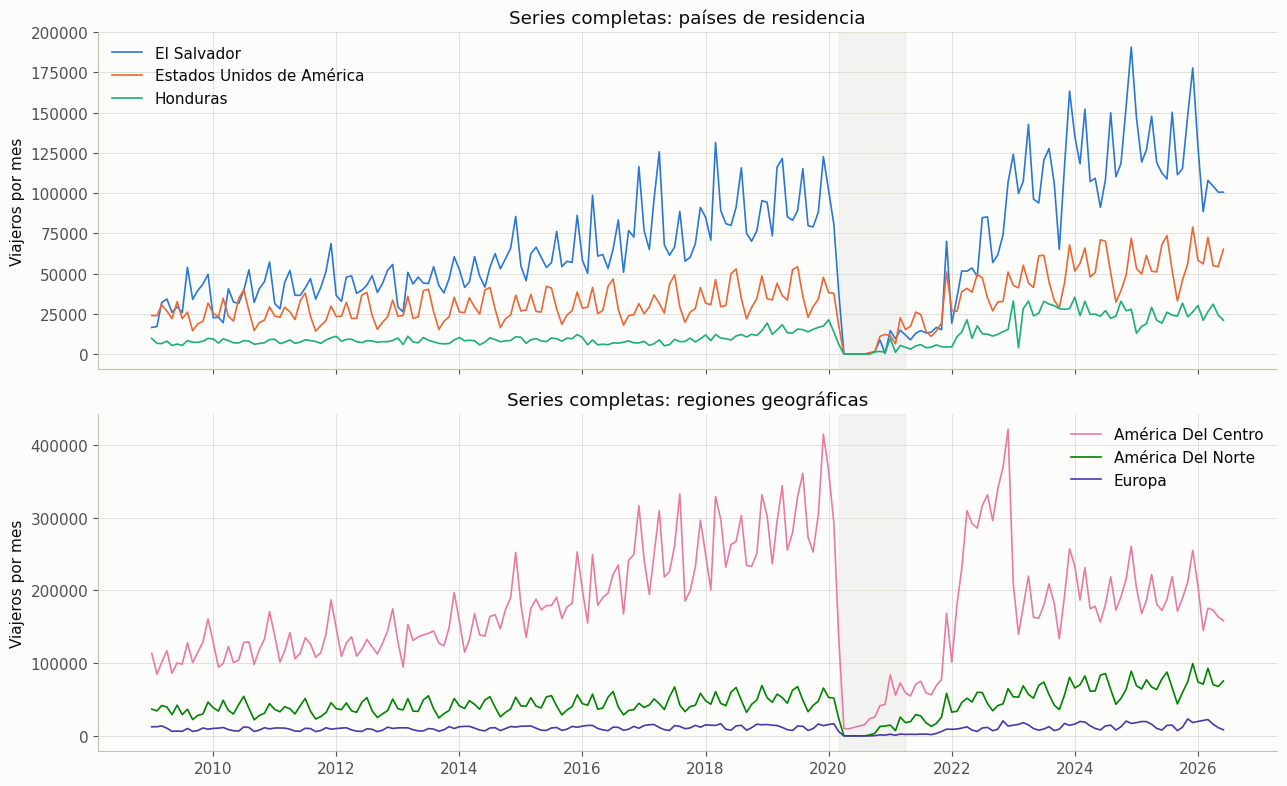

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for i, pais in enumerate(paises_top3):
    axes[0].plot(series_dict[pais].index, series_dict[pais].values, color=PALETTE[i], linewidth=1.2, label=pais)
axes[0].set_title("Series completas: países de residencia")
axes[0].legend(frameon=False)

for i, region in enumerate(regiones_top3):
    axes[1].plot(series_dict[region].index, series_dict[region].values, color=PALETTE[i + 4], linewidth=1.2, label=region)
axes[1].set_title("Series completas: regiones geográficas")
axes[1].legend(frameon=False)

for ax in axes:
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-03-31"), color="gray", alpha=0.08)
    ax.set_ylabel("Viajeros por mes")

plt.tight_layout()
plt.show()

## 2. Ejercicio 2: catch22

### 2.1 ¿Qué es catch22 y por qué importa?

catch22 (CAnonical Time-series CHaracteristics, Fulcher, Little y Jones, 2013/2019) nace del proyecto *hctsa* (*highly comparative time-series analysis*), una librería que calcula más de 7,000 características distintas para cualquier serie de tiempo: valores como autocorrelación, entropía, fluctuaciones, distribución de valores, no linealidad, etc.

El problema con esas más de 7,000 características es que son muy redundantes entre sí (varias miden esencialmente lo mismo) y computacionalmente pesadas de calcular todas. Los autores de catch22 corrieron esas 7,000+ características sobre miles de series de datasets muy variados (finanzas, medicina, clima, procesos industriales) y se quedaron únicamente con un subconjunto de **22 características** que, en conjunto:

- Son poco redundantes entre sí (cada una captura algo que las otras 21 no captan).
- Conservan casi todo el poder de clasificación/discriminación de las más de 7,000 originales.
- Son rápidas de calcular, a diferencia del set completo de hctsa.
- Sirven para cualquier dominio, porque no se diseñaron pensando en un tipo de serie específico.

Es decir, catch22 es una forma de resumir una serie de tiempo completa (sin importar su longitud) en solo 22 números, de manera que dos series con "forma" parecida (tendencia, estacionalidad, memoria, volatilidad, etc.) queden con vectores de características parecidos, y se puedan comparar, agrupar o graficar sin tener que alinear las series en el tiempo. Es justo lo que se necesita para este ejercicio: comparar 6 series con escalas y períodos de mayor actividad distintos, a partir de su forma y no de sus valores absolutos.

### 2.2 Extracción de las 22 características por serie

In [5]:
catch22_resultados = {}
for nombre, serie in series_dict.items():
    res = pycatch22.catch22_all(serie.values.tolist())
    catch22_resultados[nombre] = dict(zip(res["names"], res["values"]))

nombres_features = list(next(iter(catch22_resultados.values())).keys())
print(f"{len(catch22_resultados)} series, {len(nombres_features)} características por serie")
pd.DataFrame(catch22_resultados[paises_top3[0]], index=[paises_top3[0]])

6 series, 22 características por serie


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
El Salvador,-0.25181,-0.494924,13.998392,2,0.345884,-0.009693,0.889952,31.0,0.020833,3,0.377974,1.0,0.038462,0.766667,0.309524,0.847661,5.0,1.803352,0.142857,0.857143,0.073631,0.537345


### 2.3 Matriz de características (series x catch22)

In [6]:
matriz_catch22 = pd.DataFrame(catch22_resultados).T
matriz_catch22 = matriz_catch22[nombres_features]  # conserva el orden original de catch22
matriz_catch22.index.name = "Serie"
matriz_catch22

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,,
El Salvador,-0.251810,-0.494924,13.998392,2.0,0.345884,-0.009693,0.889952,31.0,0.020833,3.0,0.377974,1.0,0.038462,0.766667,0.309524,0.847661,5.0,1.803352,0.142857,0.857143,0.073631,0.537345
Estados Unidos de América,-0.618139,-0.361137,9.264622,2.0,0.256037,0.019514,0.909091,12.0,0.020833,5.0,0.265592,1.0,0.038462,0.828571,0.323810,0.724049,5.0,1.981011,0.166667,0.738095,0.098175,0.736974
Honduras,-0.176971,-0.395275,18.242108,8.0,0.452511,-0.093463,0.870813,39.0,0.055556,8.0,0.166816,7.0,0.029412,0.752381,0.319048,0.865881,5.0,1.796815,0.857143,0.738095,0.049087,0.474189
América Del Centro,-0.555608,-0.555608,8.348638,10.0,0.456909,-0.139984,0.909091,42.0,0.005510,11.0,0.243626,9.0,0.055556,0.219048,0.319048,0.831118,6.0,1.788784,0.761905,0.857143,0.147262,0.624887
América Del Norte,0.275697,-0.542167,9.134473,2.0,0.253041,-0.016483,0.952153,12.0,0.037037,3.0,0.287110,1.0,0.045455,0.828571,0.323810,0.740595,5.0,2.010477,0.166667,0.738095,0.098175,0.721577
Europa,0.240650,-0.013271,4.522684,2.0,0.336800,0.058315,0.918660,8.0,0.013889,7.0,0.226234,1.0,0.058824,0.738095,0.333333,0.766695,6.0,2.044771,0.142857,0.738095,0.171806,0.773784


### 2.4 Estandarización de las características

Antes de comparar, cada columna (característica) se estandariza a media 0 y desviación estándar 1. Es necesario porque las 22 características de catch22 no están en la misma escala entre sí (unas son proporciones entre 0 y 1, otras son conteos, otras son estadísticos de autocorrelación), así que sin estandarizar, las características con rangos más grandes dominarían cualquier distancia, PCA o clustering que se calcule después.

In [7]:
from sklearn.preprocessing import StandardScaler

scaler_catch22 = StandardScaler()
matriz_catch22_std = pd.DataFrame(
    scaler_catch22.fit_transform(matriz_catch22),
    index=matriz_catch22.index,
    columns=matriz_catch22.columns,
)
matriz_catch22_std.round(2)

,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5,CO_trev_1_num,MD_hrv_classic_pnn40,SB_BinaryStats_mean_longstretch1,SB_TransitionMatrix_3ac_sumdiagcov,PD_PeriodicityWang_th0_01,CO_Embed2_Dist_tau_d_expfit_meandiff,IN_AutoMutualInfoStats_40_gaussian_fmmi,FC_LocalSimple_mean1_tauresrat,DN_OutlierInclude_p_001_mdrmd,DN_OutlierInclude_n_001_mdrmd,SP_Summaries_welch_rect_area_5_1,SB_BinaryStats_diff_longstretch0,SB_MotifThree_quantile_hh,SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,SP_Summaries_welch_rect_centroid,FC_LocalSimple_mean3_stderr
Serie,,,,,,,,,,,,,,,,,,,,,,
El Salvador,-0.20,-0.55,0.78,-0.70,-0.05,0.31,-0.73,0.51,-0.29,-1.11,1.82,-0.70,-0.58,0.37,-1.67,0.95,-0.71,-0.92,-0.74,1.41,-0.78,-0.98
Estados Unidos de América,-1.26,0.18,-0.30,-0.70,-1.15,0.74,0.03,-0.87,-0.29,-0.41,0.07,-0.70,-0.58,0.66,0.33,-1.32,-0.71,0.70,-0.67,-0.71,-0.20,0.84
Honduras,0.01,-0.01,1.74,1.09,1.25,-0.94,-1.49,1.09,1.83,0.64,-1.47,1.09,-1.46,0.30,-0.33,1.28,-0.71,-0.98,1.56,-0.71,-1.37,-1.56
América Del Centro,-1.08,-0.88,-0.51,1.69,1.30,-1.64,0.03,1.30,-1.23,1.69,-0.27,1.69,1.09,-2.21,-0.33,0.64,1.41,-1.05,1.25,1.41,0.98,-0.18
América Del Norte,1.32,-0.80,-0.33,-0.70,-1.18,0.21,1.75,-0.87,0.70,-1.11,0.40,-0.70,0.11,0.66,0.33,-1.01,-0.71,0.97,-0.67,-0.71,-0.20,0.70
Europa,1.21,2.06,-1.38,-0.70,-0.16,1.32,0.41,-1.16,-0.71,0.29,-0.54,-0.70,1.41,0.23,1.67,-0.54,1.41,1.28,-0.74,-0.71,1.57,1.18


In [8]:
# Se guardan ambas matrices en csv, para que el resto del análisis (2.5 en adelante)
# se pueda retomar sin tener que volver a correr pycatch22.
matriz_catch22.to_csv("catch22_features_raw.csv")
matriz_catch22_std.to_csv("catch22_features_estandarizadas.csv")
print("Guardado: catch22_features_raw.csv y catch22_features_estandarizadas.csv")

Guardado: catch22_features_raw.csv y catch22_features_estandarizadas.csv
